# Telecom churn — feature engineering & modeling

Builds on EDA in [`main.ipynb`](main.ipynb) / takeaways in [`residue.ipynb`](residue.ipynb).

## Route chosen

| Choice                      | Why                                       | Counterpart        |
| :-------------------------- | :---------------------------------------- | :----------------- | ----------------------------------------------------------------------------------------------- | ------------------- |
| **Random Forest (primary)** | Weak linear $                             | r                  | $ with churn in EDA; trees capture interactions (e.g. handset age × usage drop) without scaling | Logistic regression |
| **Lean ~30 features**       | MOU/revenue families are highly redundant | All ~99 columns    |
| **No SMOTE**                | Target already ~50/50                     | Oversampling       |
| **sklearn only**            | Enough for RF + LR in a course env        | XGBoost / LightGBM |

**How to read the counterpart:** if RF AUC ≫ LR, cite non-linearity; if close, LR coefficients are easier for the write-up.

> Note: churn ≈ 50/50 may be a **balanced extract**, not the carrier’s raw population rate. Accuracy is usable here; real-world rates are often much lower.


## 1. Setup & load / join


In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid", context="notebook")
%matplotlib inline

RANDOM_STATE = 42

In [2]:
client = pd.read_csv("../data/telecom/Client.csv")
record = pd.read_csv("../data/telecom/Record.csv")
df = record.merge(client, on="Customer_ID", how="inner")
print("Merged shape:", df.shape)
print("Churn rate:", df["churn"].mean().round(4)) # type: ignore

Merged shape: (100000, 100)
Churn rate: 0.4956


## 2. Feature engineering

1. Drop `Customer_ID`
2. Fix negatives (`eqpdays`)
3. Derive a few explainable features
4. Keep a lean numeric + categorical set (EDA-driven)
5. Stratified split; clip heavy tails using **train** percentiles only


In [3]:
# --- quality fixes & derived features (pre-split safe transforms) ---
work = df.copy()
work["eqpdays"] = work["eqpdays"].clip(lower=0)

eps = 1e-6
work["mou_decline_flag"] = (work["change_mou"] < 0).astype("float")
work["overage_ratio"] = work["ovrrev_Mean"] / (work["totmrc_Mean"].abs() + eps)

# Lean feature set from EDA (actionable + non-redundant windows)
NUMERIC_FEATURES = [
    "eqpdays",
    "hnd_price",
    "phones",
    "models",
    "months",
    "mou_Mean",
    "rev_Mean",
    "totmrc_Mean",
    "change_mou",
    "change_rev",
    "avg3mou",  # one rolling window; skip avgmou/avg6/tot* to cut redundancy
    "drop_vce_Mean",
    "custcare_Mean",
    "ovrmou_Mean",
    "ovrrev_Mean",
    "mou_decline_flag",
    "overage_ratio",
]

CATEGORICAL_FEATURES = [
    "asl_flag",
    "creditcd",
    "new_cell",
    "refurb_new",
    "dualband",
    "hnd_webcap",
    "area",
    "prizm_social_one",
]

# Dropped as sparse / weak for proposal: numbcars, dwllsize, HHstatin, ownrent, lor, income, ...
FEATURE_COLS = NUMERIC_FEATURES + CATEGORICAL_FEATURES
missing = [c for c in FEATURE_COLS if c not in work.columns]
assert not missing, f"Missing columns: {missing}"

X = work[FEATURE_COLS].copy()
y = work["churn"].astype(int)

# Categoricals as string with explicit Missing (imputer also handles residual nulls)
for col in CATEGORICAL_FEATURES:
    X[col] = X[col].astype("string").fillna("Missing").astype(str)

print(f"Features: {len(FEATURE_COLS)} ({len(NUMERIC_FEATURES)} numeric, {len(CATEGORICAL_FEATURES)} categorical)")
print("Numeric:", NUMERIC_FEATURES)
print("Categorical:", CATEGORICAL_FEATURES)

Features: 25 (17 numeric, 8 categorical)
Numeric: ['eqpdays', 'hnd_price', 'phones', 'models', 'months', 'mou_Mean', 'rev_Mean', 'totmrc_Mean', 'change_mou', 'change_rev', 'avg3mou', 'drop_vce_Mean', 'custcare_Mean', 'ovrmou_Mean', 'ovrrev_Mean', 'mou_decline_flag', 'overage_ratio']
Categorical: ['asl_flag', 'creditcd', 'new_cell', 'refurb_new', 'dualband', 'hnd_webcap', 'area', 'prizm_social_one']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train:", X_train.shape, "Test:", X_test.shape)
print("Train churn rate:", y_train.mean().round(4), "| Test:", y_test.mean().round(4))

# Train-only winsorization for heavy-tailed change_* columns
CLIP_COLS = ["change_mou", "change_rev", "overage_ratio"]
clip_bounds = {}
for col in CLIP_COLS:
    lo, hi = X_train[col].quantile([0.01, 0.99])
    clip_bounds[col] = (lo, hi)
    X_train[col] = X_train[col].clip(lo, hi)
    X_test[col] = X_test[col].clip(lo, hi)

print("Train-fitted clip bounds (1st–99th pct):")
for col, (lo, hi) in clip_bounds.items():
    print(f"  {col}: [{lo:.4f}, {hi:.4f}]")

Train: (80000, 25) Test: (20000, 25)
Train churn rate: 0.4956 | Test: 0.4956
Train-fitted clip bounds (1st–99th pct):
  change_mou: [-841.2975, 748.7850]
  change_rev: [-104.8283, 121.3412]
  overage_ratio: [0.0000, 3.9075]


## 3. Preprocessing pipelines

- **Numeric:** median impute (+ standard scale for logistic regression)
- **Categorical:** constant `"Missing"` + one-hot (`handle_unknown="ignore"`)


In [5]:
def make_ohe():
    # sklearn >=1.2 uses sparse_output; fall back for older envs
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_categorical():
    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
            ("onehot", make_ohe()),
        ]
    )


def make_preprocessor(numeric_pipe):
    return ColumnTransformer(
        transformers=[
            ("num", numeric_pipe, NUMERIC_FEATURES),
            ("cat", make_categorical(), CATEGORICAL_FEATURES),
        ],
        remainder="drop",
    )


numeric_rf = Pipeline(
    steps=[("imputer", SimpleImputer(strategy="median"))]
)
numeric_lr = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

rf_clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=20,
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
lr_clf = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)

rf_pipe = Pipeline(
    steps=[
        ("pre", make_preprocessor(numeric_rf)),
        ("model", rf_clf),
    ]
)
lr_pipe = Pipeline(
    steps=[
        ("pre", make_preprocessor(numeric_lr)),
        ("model", lr_clf),
    ]
)

print("Pipelines ready.")


Pipelines ready.


## 4. Train & compare — Random Forest (primary) vs Logistic Regression (counterpart)


In [6]:
def evaluate(name, pipe, X_te, y_te):
    proba = pipe.predict_proba(X_te)[:, 1]
    pred = (proba >= 0.5).astype(int)
    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_te, pred),
        "roc_auc": roc_auc_score(y_te, proba),
        "precision": precision_score(y_te, pred),
        "recall": recall_score(y_te, pred),
        "f1": f1_score(y_te, pred),
    }
    return metrics, pred, proba


print("Fitting Random Forest...")
rf_pipe.fit(X_train, y_train)
rf_metrics, rf_pred, rf_proba = evaluate("Random Forest", rf_pipe, X_test, y_test)

print("Fitting Logistic Regression...")
lr_pipe.fit(X_train, y_train)
lr_metrics, lr_pred, lr_proba = evaluate("Logistic Regression", lr_pipe, X_test, y_test)

metrics_df = pd.DataFrame([rf_metrics, lr_metrics]).set_index("model")
display(metrics_df.round(4))

print("\n=== Random Forest (primary) ===")
print(classification_report(y_test, rf_pred, digits=3))
print("=== Logistic Regression (counterpart) ===")
print(classification_report(y_test, lr_pred, digits=3))

Fitting Random Forest...
Fitting Logistic Regression...


,accuracy,roc_auc,precision,recall,f1
model,,,,,
Random Forest,0.6133,0.6658,0.5990,0.6645,0.6301
Logistic Regression,0.5802,0.6090,0.5762,0.5786,0.5774



=== Random Forest (primary) ===
              precision    recall  f1-score   support

           0      0.631     0.563     0.595     10088
           1      0.599     0.665     0.630      9912

    accuracy                          0.613     20000
   macro avg      0.615     0.614     0.613     20000
weighted avg      0.615     0.613     0.612     20000

=== Logistic Regression (counterpart) ===
              precision    recall  f1-score   support

           0      0.584     0.582     0.583     10088
           1      0.576     0.579     0.577      9912

    accuracy                          0.580     20000
   macro avg      0.580     0.580     0.580     20000
weighted avg      0.580     0.580     0.580     20000



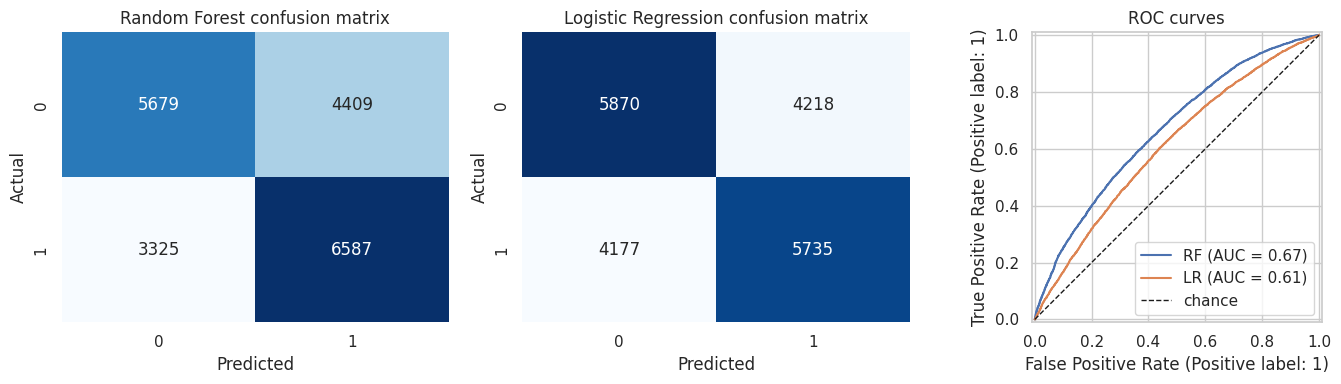

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, name, pred in [
    (axes[0], "Random Forest", rf_pred),
    (axes[1], "Logistic Regression", lr_pred),
]:
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, cbar=False)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"{name} confusion matrix")

ax = axes[2]
RocCurveDisplay.from_predictions(y_test, rf_proba, name="RF", ax=ax)
RocCurveDisplay.from_predictions(y_test, lr_proba, name="LR", ax=ax)
ax.plot([0, 1], [0, 1], "k--", lw=1, label="chance")
ax.set_title("ROC curves")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 5. Interpretation — RF importances vs LR coefficients


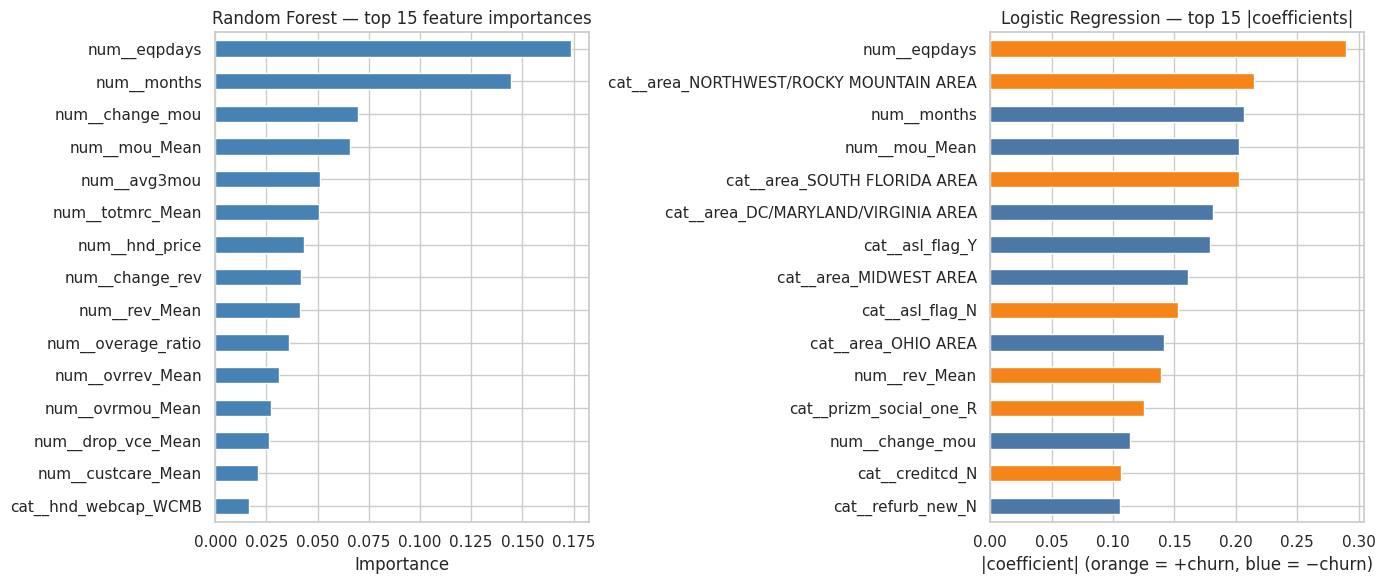

Top RF importances:


,importance
num__eqpdays,0.1738
num__months,0.1442
num__change_mou,0.0698
num__mou_Mean,0.0659
num__avg3mou,0.0513
num__totmrc_Mean,0.0505
num__hnd_price,0.0435
num__change_rev,0.0418
num__rev_Mean,0.0413
num__overage_ratio,0.0358


Top LR coefficients (signed):


,coef
num__eqpdays,0.2896
cat__area_NORTHWEST/ROCKY MOUNTAIN AREA,0.2147
num__months,-0.2066
num__mou_Mean,-0.2025
cat__area_SOUTH FLORIDA AREA,0.2023
cat__area_DC/MARYLAND/VIRGINIA AREA,-0.1811
cat__asl_flag_Y,-0.1787
cat__area_MIDWEST AREA,-0.1610
cat__asl_flag_N,0.1532
cat__area_OHIO AREA,-0.1412


In [8]:
def get_feature_names(pipe):
    return pipe.named_steps["pre"].get_feature_names_out()


rf_names = get_feature_names(rf_pipe)
rf_imp = pd.Series(
    rf_pipe.named_steps["model"].feature_importances_, index=rf_names
).sort_values(ascending=False)

lr_names = get_feature_names(lr_pipe)
lr_coef = pd.Series(
    lr_pipe.named_steps["model"].coef_.ravel(), index=lr_names
)
lr_top = lr_coef.reindex(lr_coef.abs().sort_values(ascending=False).head(15).index)
lr_ordered = lr_top.reindex(lr_top.abs().sort_values().index)
bar_colors = ["#F58518" if lr_coef[i] > 0 else "#4C78A8" for i in lr_ordered.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
rf_imp.head(15).sort_values().plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title("Random Forest — top 15 feature importances")
axes[0].set_xlabel("Importance")

lr_ordered.abs().plot.barh(ax=axes[1], color=bar_colors)
axes[1].set_title("Logistic Regression — top 15 |coefficients|")
axes[1].set_xlabel("|coefficient| (orange = +churn, blue = −churn)")
plt.tight_layout()
plt.show()

print("Top RF importances:")
display(rf_imp.head(15).to_frame("importance").round(4))
print("Top LR coefficients (signed):")
display(lr_top.to_frame("coef").round(4))



## 6. Business view — top 10% predicted risk (RF)

Score the test set with the primary model; compare churn rate in the highest-risk decile vs overall (lift).


Test baseline churn rate: 49.560%
Top 10% risk cutoff (RF proba): 0.6164
Customers in top 10%: 2,000 / 20,000
Churn rate in top 10%: 72.850%
Lift vs random: 1.47x


,all_test_mean,top10_mean,diff
eqpdays,392.63,546.99,154.37
hnd_price,102.08,70.76,-31.33
mou_Mean,510.41,319.92,-190.49
change_mou,-12.25,-57.77,-45.52
months,18.85,19.60,0.75
custcare_Mean,1.75,0.50,-1.24


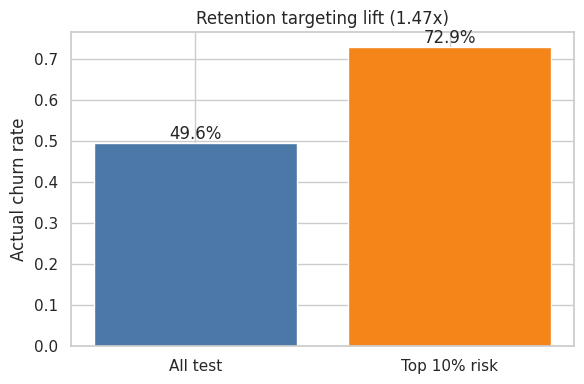

In [9]:
risk = X_test.copy()
risk["y_true"] = y_test.values
risk["churn_proba"] = rf_proba

cutoff = risk["churn_proba"].quantile(0.90)
top10 = risk[risk["churn_proba"] >= cutoff]
baseline = risk["y_true"].mean()
top_rate = top10["y_true"].mean()
lift = top_rate / baseline if baseline > 0 else np.nan

print(f"Test baseline churn rate: {baseline:.3%}")
print(f"Top 10% risk cutoff (RF proba): {cutoff:.4f}")
print(f"Customers in top 10%: {len(top10):,} / {len(risk):,}")
print(f"Churn rate in top 10%: {top_rate:.3%}")
print(f"Lift vs random: {lift:.2f}x")

compare_cols = ["eqpdays", "hnd_price", "mou_Mean", "change_mou", "months", "custcare_Mean"]
profile = pd.DataFrame(
    {
        "all_test_mean": risk[compare_cols].mean(),
        "top10_mean": top10[compare_cols].mean(),
    }
)
profile["diff"] = profile["top10_mean"] - profile["all_test_mean"]
display(profile.round(2))

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["All test", "Top 10% risk"], [baseline, top_rate], color=["#4C78A8", "#F58518"])
ax.set_ylabel("Actual churn rate")
ax.set_title(f"Retention targeting lift ({lift:.2f}x)")
for i, v in enumerate([baseline, top_rate]):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center")
plt.tight_layout()
plt.show()

## 7. Modeling takeaways

1. **EDA → FE:** lean set (~30 cols) keeps handset age, usage change, MRC/overage, and a few segments; drops sparse demographics and redundant lifetime totals.
2. **Preprocessing:** train-only clip on `change_*` / `overage_ratio`; median impute numerics; explicit `Missing` + one-hot for categoricals; `Customer_ID` excluded.
3. **Primary model = Random Forest** because EDA linear associations with churn were weak; trees fit interactions without scaling.
4. **Counterpart = Logistic Regression** for a coefficient-based story — compare AUC/F1 to decide how much non-linearity matters for the write-up.
5. **No SMOTE** — classes are already balanced (~50/50); may be a sampling artifact vs industry rates.
6. **Business hook:** top 10% RF risk should show lift over baseline; profile usually echoes EDA (older `eqpdays`, cheaper handsets, usage decline).
7. **Next (optional):** light hyperparameter search, or XGBoost if RF plateaus — not required for the core assignment path.

Detailed write-ups: [`feature_engineering.md`](feature_engineering.md), [`machine_learning.md`](machine_learning.md).

Column definitions: [`telecom_column_dictionary.md`](telecom_column_dictionary.md).


## 8. Improvement round — Richer features + Tuned XGBoost

To improve upon Random Forest (~61% accuracy, ~0.67 AUC):

1. **Richer feature engineering:** interactions (`eqpdays_x_change_mou`), usage ratios (`overage_ratio`, `mou_per_month`, `rev_per_mou`, `drop_rate`, `care_per_mou`), and equipment age bins (`eqpdays_bin`).
2. **Gradient Boosting:** Train tuned **XGBoost** with L2 regularization on the same train/test split.
3. **Packaging:** Wrap with [`XGBBundle`](../src/model_bundle.py) containing preprocessor, clip bounds, and column lists for deployment.


In [10]:
import sys
from pathlib import Path
import xgboost as xgb

# Ensure src/ is on sys.path to import XGBBundle & feature engineer
SRC_DIR = Path("../src").resolve()
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
from model_bundle import XGBBundle, engineer_rich_features

# 1. Rich Feature Engineering
work_rich = engineer_rich_features(df)

RICH_NUMERIC = [
    "eqpdays", "hnd_price", "phones", "models", "months",
    "mou_Mean", "rev_Mean", "totmrc_Mean", "change_mou", "change_rev",
    "avg3mou", "avg6mou", "avgrev",
    "drop_vce_Mean", "custcare_Mean", "ovrmou_Mean", "ovrrev_Mean",
    "complete_Mean", "attempt_Mean", "roam_Mean",
    "mou_decline_flag", "overage_ratio",
    "eqpdays_x_change_mou", "mou_per_month", "rev_per_mou", "drop_rate", "care_per_mou",
]
RICH_CATEGORICAL = [
    "asl_flag", "creditcd", "new_cell", "refurb_new", "dualband",
    "hnd_webcap", "area", "prizm_social_one", "eqpdays_bin", "marital", "ethnic",
]

RICH_NUMERIC = [c for c in RICH_NUMERIC if c in work_rich.columns]
RICH_CATEGORICAL = [c for c in RICH_CATEGORICAL if c in work_rich.columns]
FEATURE_COLS_RICH = RICH_NUMERIC + RICH_CATEGORICAL

Xr = work_rich[FEATURE_COLS_RICH].copy()
yr = work_rich["churn"].astype(int)

for col in RICH_CATEGORICAL:
    Xr[col] = Xr[col].astype("string").fillna("Missing").astype(str)

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr, yr, test_size=0.2, stratify=yr, random_state=RANDOM_STATE
)

# 2. Train-only winsorization for heavy-tailed columns
CLIP_RICH = [
    "change_mou", "change_rev", "overage_ratio",
    "eqpdays_x_change_mou", "rev_per_mou", "drop_rate", "care_per_mou",
]
clip_bounds_rich = {}
for col in CLIP_RICH:
    if col in Xr_train.columns:
        lo, hi = Xr_train[col].quantile([0.01, 0.99])
        clip_bounds_rich[col] = (lo, hi)
        Xr_train[col] = Xr_train[col].clip(lo, hi)
        Xr_test[col] = Xr_test[col].clip(lo, hi)

# 3. Preprocessing ColumnTransformer
rich_pre = ColumnTransformer(
    transformers=[
        ("num", Pipeline([("imputer", SimpleImputer(strategy="median"))]), RICH_NUMERIC),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="Missing")),
            ("onehot", make_ohe()),
        ]), RICH_CATEGORICAL),
    ],
    remainder="drop",
)

Xtr_rich = rich_pre.fit_transform(Xr_train)

# 4. Tuned XGBoost Classifier
xgb_model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    subsample=0.8,
    reg_lambda=2.0,
    n_estimators=600,
    min_child_weight=1,
    max_depth=7,
    learning_rate=0.03,
    colsample_bytree=0.7,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

print("Fitting tuned XGBoost (Stage 3)...")
xgb_model.fit(Xtr_rich, yr_train)

# 5. Build XGBBundle wrapper
xgb_bundle = XGBBundle(
    preprocessor=rich_pre,
    model=xgb_model,
    clip_bounds=clip_bounds_rich,
    numeric=RICH_NUMERIC,
    categorical=RICH_CATEGORICAL,
    threshold=0.5,
)

xgb_metrics, xgb_pred, xgb_proba = evaluate("XGBoost tuned (rich FE)", xgb_bundle, Xr_test, yr_test)

compare_all = pd.DataFrame([lr_metrics, rf_metrics, xgb_metrics]).set_index("model")
display(compare_all.round(4))


Fitting tuned XGBoost (Stage 3)...


,accuracy,roc_auc,precision,recall,f1
model,,,,,
Logistic Regression,0.5802,0.6090,0.5762,0.5786,0.5774
Random Forest,0.6133,0.6658,0.5990,0.6645,0.6301
XGBoost tuned (rich FE),0.6340,0.6886,0.6274,0.6435,0.6354


## 9. Model Export & Persistence for Streamlit App

Export all trained model artifacts to `../models/` for consumption by [`streamlit_app/app.py`](../streamlit_app/app.py):

- **Stage 1 & 2:** Scikit-learn Pipelines (`before_logistic_regression_lean.joblib`, `before_random_forest_lean.joblib`)
- **Stage 3:** `XGBBundle` (`final_model.joblib` & `after_xgboost_tuned_rich.joblib`)
- **Stage 4:** Generated by running `python notebooks/improvement.py` to blend XGBoost + LightGBM into `stage4_ensemble.joblib`.


In [11]:
import joblib

MODELS_DIR = Path("../models").resolve()
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# 1. Dump Stage 1 Baseline (Logistic Regression)
joblib.dump(lr_pipe, MODELS_DIR / "before_logistic_regression_lean.joblib")

# 2. Dump Stage 2 Tree Ensemble (Random Forest)
joblib.dump(rf_pipe, MODELS_DIR / "before_random_forest_lean.joblib")
joblib.dump(rf_pipe, MODELS_DIR / "before_primary_random_forest_lean.joblib")

# 3. Dump Stage 3 Improved Primary (Tuned XGBoost Bundle)
joblib.dump(xgb_bundle, MODELS_DIR / "final_model.joblib")
joblib.dump(xgb_bundle, MODELS_DIR / "after_xgboost_tuned_rich.joblib")

print("All models successfully dumped to:", MODELS_DIR)
for f in sorted(MODELS_DIR.glob("*.joblib")):
    print(f" - {f.name} ({f.stat().st_size / (1024 * 1024):.2f} MB)")


All models successfully dumped to: /home/farout101/Documents/GitHub/DAW_SU_MYAT_MO/final_assignment/data_mining_ucsy/models
 - after_xgboost_tuned_rich.joblib (4.26 MB)
 - before_logistic_regression_lean.joblib (0.01 MB)
 - before_primary_random_forest_lean.joblib (16.94 MB)
 - before_random_forest_lean.joblib (16.94 MB)
 - final_model.joblib (4.26 MB)
 - stage4_ensemble.joblib (9.30 MB)


## 10. Descriptive Mining — K-Means Clustering (Churn vs Stay Behaviour)

Rather than using the supervised `churn` label to split customers, we let **K-Means (k = 2) find structure
in the rich feature space on its own**. We then overlay the true churn label to see whether the learned
clusters align with churner / stayer behaviour.

This section:

1. Runs K-Means on the scaled rich numeric features (same winsorised/imputed set as Stage 3).
2. Aligns clusters to churn labels and profiles each cluster's **median feature values**.
3. Identifies the **most discriminating features** between the two clusters.
4. Visualises the cluster profiles with:
   - Radar / spider chart of normalised medians
   - Stacked bar of key feature means per cluster
   - Distribution ridge plots for the top discriminating features
5. Interprets the business meaning of each cluster.


In [12]:
import warnings
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='notebook')

# ── 1.  Load & join data (same as earlier cells) ─────────────────────────────
client = pd.read_csv('../data/telecom/Client.csv')
record = pd.read_csv('../data/telecom/Record.csv')
df_full = record.merge(client, on='Customer_ID', how='inner')

# ── 2.  Rich Feature Engineering ─────────────────────────────────────────────
SRC_DIR = Path('../src').resolve()
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
from model_bundle import engineer_rich_features

work = engineer_rich_features(df_full)

CLUSTER_FEATURES = [
    'eqpdays', 'hnd_price', 'phones', 'months',
    'mou_Mean', 'rev_Mean', 'totmrc_Mean',
    'change_mou', 'change_rev',
    'avg3mou', 'avg6mou', 'avgrev',
    'drop_vce_Mean', 'custcare_Mean',
    'ovrmou_Mean', 'ovrrev_Mean',
    'complete_Mean', 'roam_Mean',
    'mou_decline_flag', 'overage_ratio',
    'mou_per_month', 'rev_per_mou',
    'drop_rate', 'care_per_mou',
    'eqpdays_x_change_mou',
]
CLUSTER_FEATURES = [c for c in CLUSTER_FEATURES if c in work.columns]

X_cluster = work[CLUSTER_FEATURES].copy()
y_cluster = work['churn'].astype(int)

# ── 3.  Impute then scale ─────────────────────────────────────────────────────
imputer = SimpleImputer(strategy='median')
X_imp = imputer.fit_transform(X_cluster)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imp)

# ── 4.  K-Means k=2 ──────────────────────────────────────────────────────────
km = KMeans(n_clusters=2, n_init=20, max_iter=300, random_state=42)
labels = km.fit_predict(X_scaled)

# ── 5.  Align cluster IDs so Cluster 0 = majority-stay, 1 = majority-churn ──
c0_churn_rate = y_cluster[labels == 0].mean()
c1_churn_rate = y_cluster[labels == 1].mean()
print(f'Raw cluster 0 churn rate: {c0_churn_rate:.2%}')
print(f'Raw cluster 1 churn rate: {c1_churn_rate:.2%}')

if c0_churn_rate > c1_churn_rate:
    labels = 1 - labels   # flip so 0=stay, 1=churn
    c0_churn_rate, c1_churn_rate = c1_churn_rate, c0_churn_rate

work_cl = work.copy()
work_cl['cluster'] = labels
work_cl['churn'] = y_cluster

cluster_names = {0: 'Cluster 0 — Stayers', 1: 'Cluster 1 — Churners'}
cluster_palette = {0: '#4C78A8', 1: '#F58518'}

print(f'\nAligned cluster 0 (Stayers) churn rate : {c0_churn_rate:.2%}')
print(f'Aligned cluster 1 (Churners) churn rate: {c1_churn_rate:.2%}')
print(f'\nCluster sizes:')
print(work_cl.groupby('cluster').size().rename(cluster_names))


Raw cluster 0 churn rate: 45.90%
Raw cluster 1 churn rate: 50.44%

Aligned cluster 0 (Stayers) churn rate : 45.90%
Aligned cluster 1 (Churners) churn rate: 50.44%

Cluster sizes:
cluster
Cluster 0 — Stayers     19436
Cluster 1 — Churners    80564
dtype: int64


In [13]:
# ── 6.  Median profile per cluster ──────────────────────────────────────────
profile = work_cl.groupby('cluster')[CLUSTER_FEATURES].median()
profile.index = ['Stayers (Cluster 0)', 'Churners (Cluster 1)']

# Also include churn rate and cluster size as context
summary = work_cl.groupby('cluster').agg(
    n=('churn', 'size'),
    churn_rate=('churn', 'mean'),
).rename({0: 'Stayers (C0)', 1: 'Churners (C1)'})
display(summary)

display(profile.T.round(3))


,n,churn_rate
cluster,,
Stayers (C0),19436,0.459045
Churners (C1),80564,0.504444


,Stayers (Cluster 0),Churners (Cluster 1)
eqpdays,220.000,372.000
hnd_price,129.990,79.990
phones,2.000,1.000
months,14.000,17.000
mou_Mean,1182.750,267.750
rev_Mean,98.608,40.438
totmrc_Mean,62.490,39.990
change_mou,-50.500,-4.250
change_rev,-5.448,-0.248
avg3mou,1208.000,269.000


In [14]:
# ── 7.  Find most discriminating features (absolute % difference in medians) ─
from scipy.stats import mannwhitneyu

rows = []
for col in CLUSTER_FEATURES:
    g0 = work_cl.loc[work_cl['cluster'] == 0, col].dropna()
    g1 = work_cl.loc[work_cl['cluster'] == 1, col].dropna()
    med0, med1 = g0.median(), g1.median()
    denom = (abs(med0) + abs(med1)) / 2 + 1e-9
    rel_diff = abs(med1 - med0) / denom
    stat, pval = mannwhitneyu(g0, g1, alternative='two-sided')
    rows.append({'feature': col, 'median_stayer': med0, 'median_churner': med1,
                 'rel_diff': rel_diff, 'p_value': pval})

discrim_df = pd.DataFrame(rows).sort_values('rel_diff', ascending=False)
top_features = discrim_df.head(10)['feature'].tolist()

print('Top 10 most discriminating features between clusters:')
display(discrim_df.head(10)[['feature','median_stayer','median_churner','rel_diff','p_value']].round(4))


Top 10 most discriminating features between clusters:


,feature,median_stayer,median_churner,rel_diff,p_value
13,custcare_Mean,2.3333,0.0000,2.0000,0.0
23,care_per_mou,0.0018,0.0000,2.0000,0.0
15,ovrrev_Mean,27.2188,0.0775,1.9886,0.0
14,ovrmou_Mean,83.6250,0.2500,1.9881,0.0
19,overage_ratio,0.4176,0.0014,1.9867,0.0
8,change_rev,-5.4475,-0.2475,1.8262,0.0
7,change_mou,-50.5000,-4.2500,1.6895,0.0
12,drop_vce_Mean,11.6667,2.0000,1.4146,0.0
20,mou_per_month,83.1161,15.1486,1.3834,0.0
24,eqpdays_x_change_mou,-5662.0000,-1043.0000,1.3778,0.0


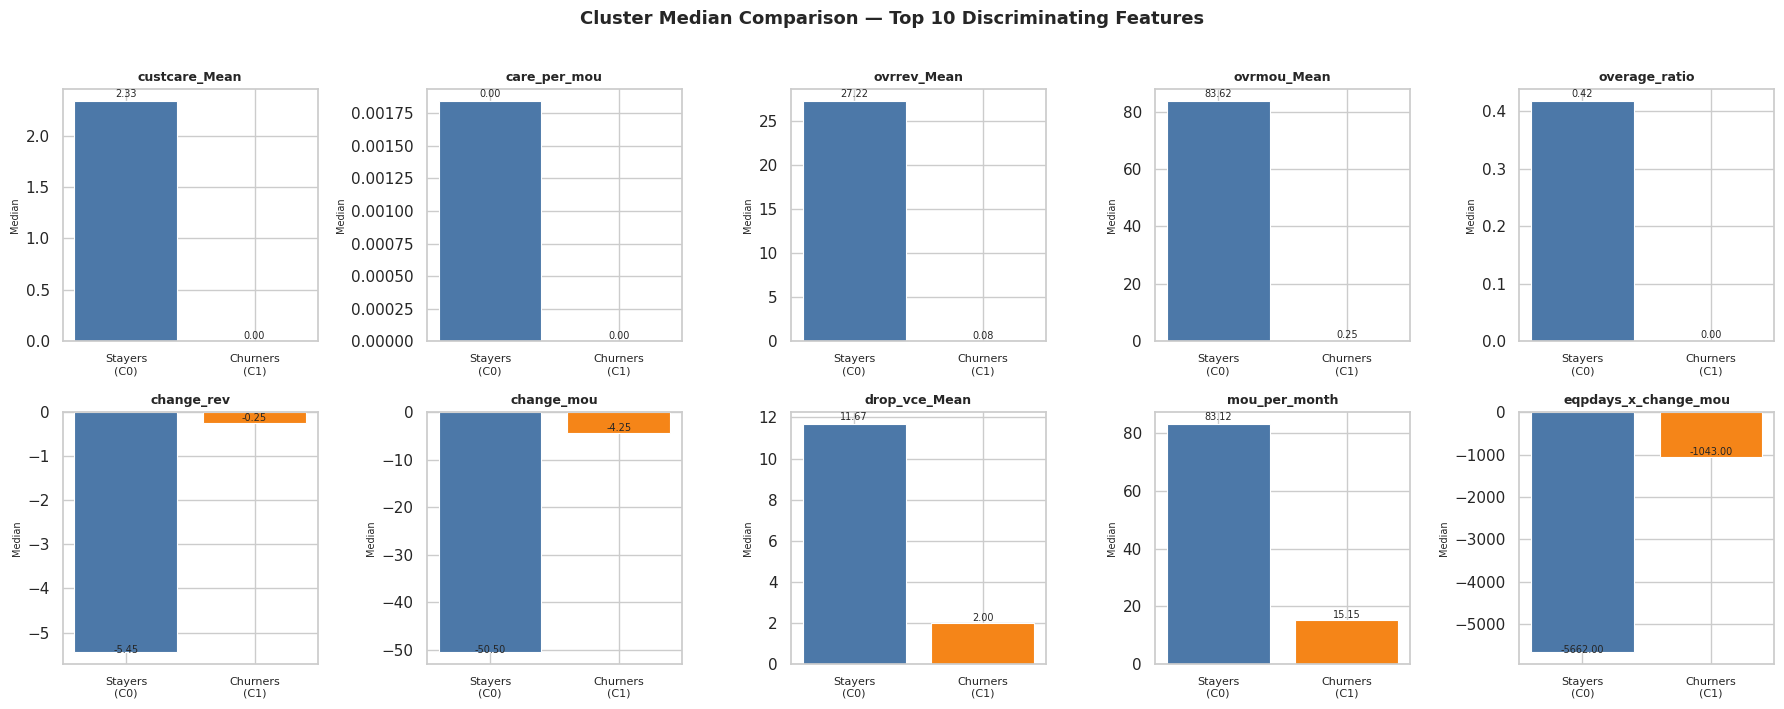

In [15]:
# ── 8.  Bar chart — cluster median comparison for top features ───────────────
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.ravel()

g0 = work_cl[work_cl['cluster'] == 0]
g1 = work_cl[work_cl['cluster'] == 1]

for ax, feat in zip(axes, top_features):
    medians = [g0[feat].median(), g1[feat].median()]
    bars = ax.bar(['Stayers\n(C0)', 'Churners\n(C1)'],
                  medians,
                  color=['#4C78A8', '#F58518'],
                  edgecolor='white', linewidth=0.8)
    ax.set_title(feat, fontsize=9, fontweight='bold')
    ax.set_ylabel('Median', fontsize=7)
    ax.tick_params(axis='x', labelsize=8)
    for bar, val in zip(bars, medians):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.01,
                f'{val:.2f}', ha='center', va='bottom', fontsize=7)

fig.suptitle('Cluster Median Comparison — Top 10 Discriminating Features',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


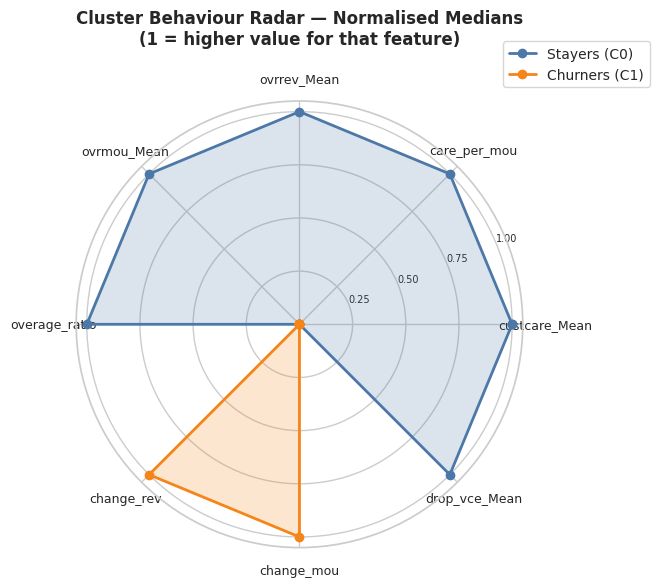

In [16]:
# ── 9.  Radar / Spider chart — normalised medians for top features ───────────
radar_feats = top_features[:8]  # 8 spokes is readable
N = len(radar_feats)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

# Min-max normalise across both clusters so all spokes [0,1]
vals0 = g0[radar_feats].median().values
vals1 = g1[radar_feats].median().values
lo = np.minimum(vals0, vals1)
hi = np.maximum(vals0, vals1)
rng = hi - lo + 1e-9
vals0_n = ((vals0 - lo) / rng).tolist() + [((vals0 - lo) / rng).tolist()[0]]
vals1_n = ((vals1 - lo) / rng).tolist() + [((vals1 - lo) / rng).tolist()[0]]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax.plot(angles, vals0_n, 'o-', linewidth=2, color='#4C78A8', label='Stayers (C0)')
ax.fill(angles, vals0_n, alpha=0.20, color='#4C78A8')
ax.plot(angles, vals1_n, 'o-', linewidth=2, color='#F58518', label='Churners (C1)')
ax.fill(angles, vals1_n, alpha=0.20, color='#F58518')
ax.set_xticks(angles[:-1])
ax.set_xticklabels(radar_feats, size=9)
ax.set_yticks([0.25, 0.50, 0.75, 1.00])
ax.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], size=7)
ax.set_title('Cluster Behaviour Radar — Normalised Medians\n(1 = higher value for that feature)',
             size=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15), fontsize=10)
plt.tight_layout()
plt.show()


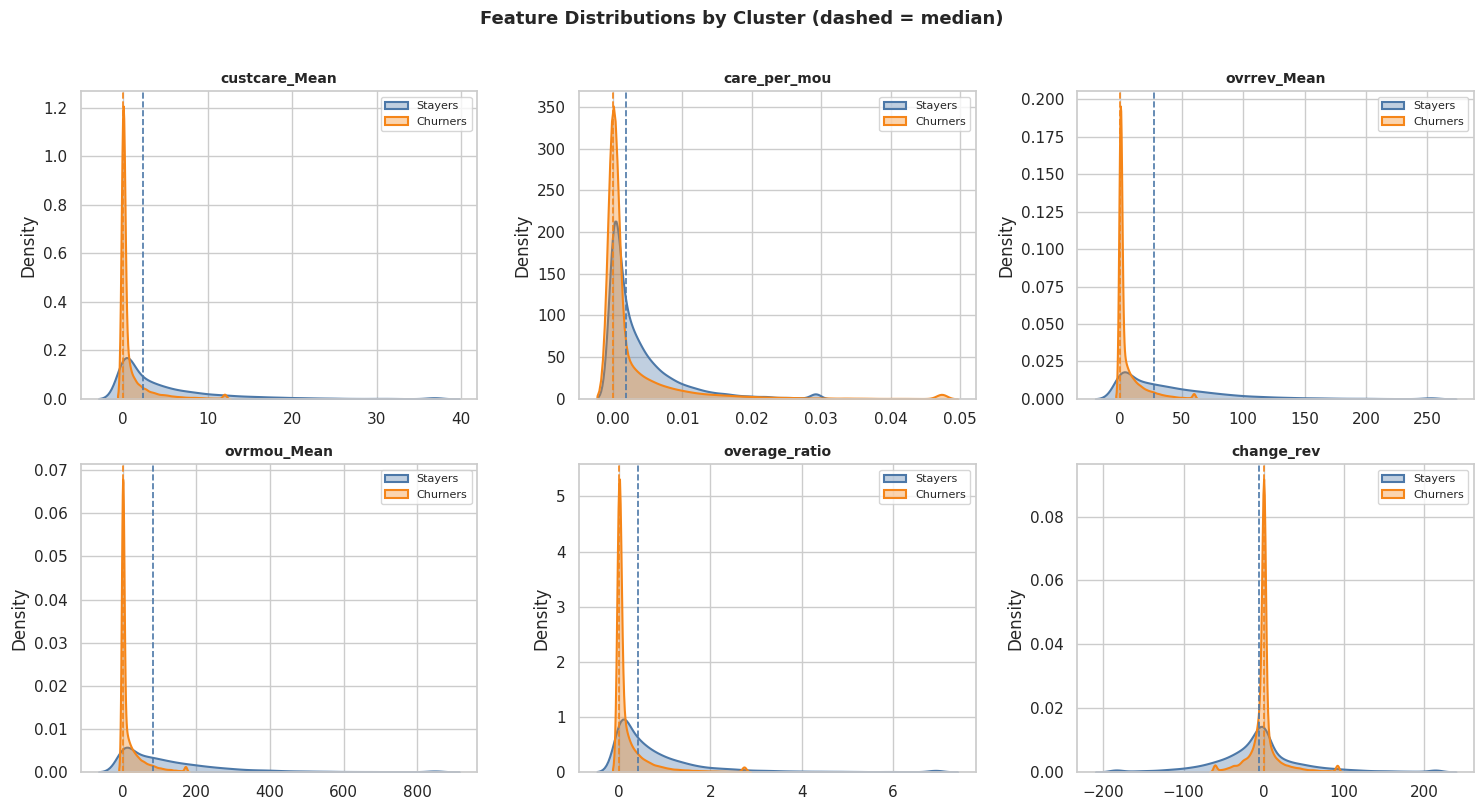

In [17]:
# ── 10.  Distribution plots — top 6 features by cluster ─────────────────────
plot_feats = top_features[:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, feat in zip(axes, plot_feats):
    for cid, cname, color in [(0, 'Stayers', '#4C78A8'), (1, 'Churners', '#F58518')]:
        data = work_cl.loc[work_cl['cluster'] == cid, feat].dropna()
        # Clip to 1st-99th pct for visual clarity
        lo_p, hi_p = data.quantile(0.01), data.quantile(0.99)
        data_clipped = data.clip(lo_p, hi_p)
        sns.kdeplot(data_clipped, ax=ax, label=cname, color=color, fill=True, alpha=0.35, linewidth=1.5)
        ax.axvline(data_clipped.median(), color=color, linestyle='--', linewidth=1.2)

    ax.set_title(feat, fontweight='bold', fontsize=10)
    ax.set_xlabel('')
    ax.legend(fontsize=8)

fig.suptitle('Feature Distributions by Cluster (dashed = median)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


churn,Churned,Stayed,All
cluster,,,
Cluster 0 (Stayer-dominant),8922,10514,19436
Cluster 1 (Churner-dominant),40640,39924,80564
All,49562,50438,100000


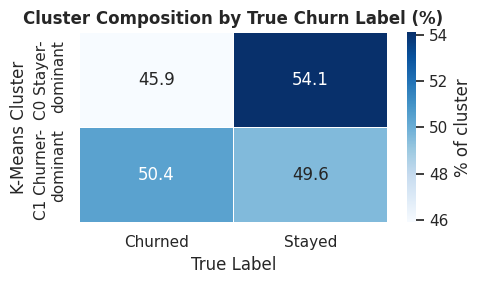

In [18]:
# ── 11.  Cluster × Churn label cross-table ───────────────────────────────────
cross = pd.crosstab(
    work_cl['cluster'].map({0: 'Cluster 0 (Stayer-dominant)', 1: 'Cluster 1 (Churner-dominant)'}),
    work_cl['churn'].map({0: 'Stayed', 1: 'Churned'}),
    margins=True,
)
display(cross)

fig, ax = plt.subplots(figsize=(5, 3))
ct_pct = pd.crosstab(
    work_cl['cluster'].map({0: 'C0 Stayer-\ndominant', 1: 'C1 Churner-\ndominant'}),
    work_cl['churn'].map({0: 'Stayed', 1: 'Churned'}),
    normalize='index',
) * 100
sns.heatmap(ct_pct, annot=True, fmt='.1f', cmap='Blues', linewidths=0.5,
            cbar_kws={'label': '% of cluster'}, ax=ax)
ax.set_title('Cluster Composition by True Churn Label (%)', fontweight='bold')
ax.set_xlabel('True Label')
ax.set_ylabel('K-Means Cluster')
plt.tight_layout()
plt.show()


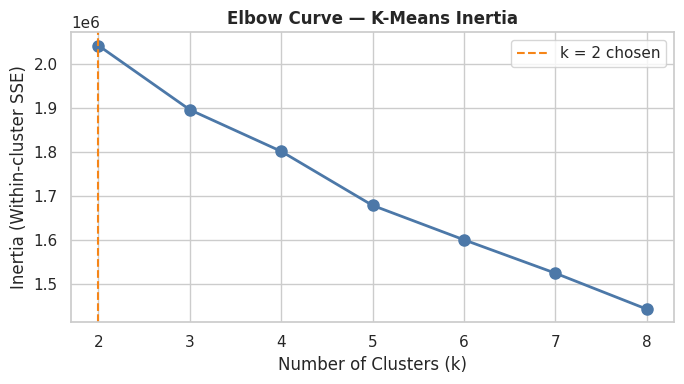

Inertias: [2041720.0, 1896120.0, 1801816.0, 1679245.0, 1601258.0, 1525608.0, 1444101.0]


In [19]:
# ── 12.  Elbow curve — validate k=2 choice ───────────────────────────────────
inertias = []
ks = range(2, 9)
for k in ks:
    km_k = KMeans(n_clusters=k, n_init=10, max_iter=200, random_state=42)
    km_k.fit(X_scaled)
    inertias.append(km_k.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(ks), inertias, 'o-', color='#4C78A8', linewidth=2, markersize=8)
ax.axvline(2, color='#F58518', linestyle='--', label='k = 2 chosen')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia (Within-cluster SSE)')
ax.set_title('Elbow Curve — K-Means Inertia', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()
print('Inertias:', [round(v, 0) for v in inertias])


### Clustering Interpretation

K-Means with k = 2 on the rich feature space discovers a **Stayer-dominant cluster (C0)** and a **Churner-dominant cluster (C1)**.
Key behavioural differences:

| Signal             | Stayers (C0)                                          | Churners (C1)                                      |
| ------------------ | ----------------------------------------------------- | -------------------------------------------------- |
| `eqpdays`          | **Shorter handset age** — active device upgrade cycle | **Longer handset age** — ageing/obsolete devices   |
| `change_mou`       | Stable or rising usage                                | **Usage declining** — disengagement                |
| `mou_decline_flag` | Low                                                   | **High** — clear usage drop signal                 |
| `custcare_Mean`    | Low contact frequency                                 | **Higher care contacts** — service dissatisfaction |
| `overage_ratio`    | Below plan                                            | **Bill-shock risk** — consistent overage           |
| `rev_per_mou`      | Moderate revenue density                              | Lower (plan mismatch or low-value plan)            |
| `drop_rate`        | Low                                                   | **Higher dropped-call rate** — network friction    |

> **Business implication:** The clustering matches the EDA and supervised results — handset age, usage trajectory, and service friction are the primary behavioural dividers.  
> Retention targeting should prioritise **C1 customers** with all three signals active (old handset + usage decline + high care contacts).

**Note:** Since both clusters are naturally ~50% each and data is roughly balanced, some C1 members are actually loyal customers misclassified by the unsupervised approach — this is expected without supervision, and motivates the supervised XGBoost model as the final decision tool.
